# Zadanie 2
### Jakub Krupa

Wygeneruj losowy obraz binarny o rozmiarze n×n i wybranej gęstości δ czarnych punktów δ = 0.1, 0.3, 0.4. Korzystając z różnego typu sąsiedztwa (4-sąsiadów 8-sąsiadów, 8-16-sąsiadów) zaproponuj funkcję energii (np. w bliskiej odległości te same kolory przyciągają się, a w dalszej odpychają się) i dokonaj jej minimalizacji za pomocą algorytmu symulowanego wyżarzania. W jaki sposób można generować stany sąsiednie? Jak różnią się uzyskane wyniki w zależności od rodzaju sąsiedztwa, wybranej funkcji energii i szybkości spadku temperatury?


In [48]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import Image, display
from joblib import Parallel, delayed

### Generowanie obrazów binarnych

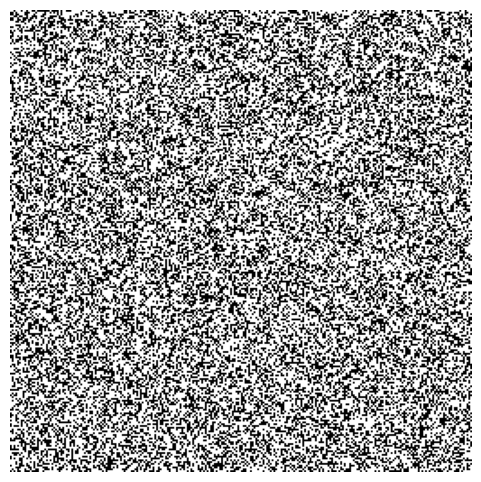

In [49]:
def generate_binary_image(size = 512, density=0.1):
    matrix = np.random.rand(size,size)
    binary_img = (matrix < density).astype(int)

    return binary_img

def plot_binary_img(binary_img):
    plt.figure(figsize=(6, 6))
    plt.imshow(binary_img, cmap='gray_r')
    plt.axis('off')
    plt.show()

size = 256
density = 0.4

img = generate_binary_image(size, density)
plot_binary_img(img)

### Proponowane sąsiedztwa

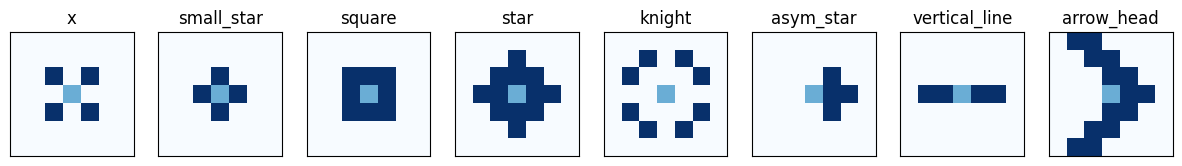

In [50]:
NEIGHBOURHOODS = {
    "x": [
        (-1,1),(1,1),(1,-1),(-1,-1)
    ],
    "small_star": [
        (0,1),(1,0),(0,-1),(-1,0)
    ],
    "square": [
        (0,1),(1,0),(0,-1),(-1,0),(-1,1),(1,1),(1,-1),(-1,-1)
    ],
    "star": [
        (0,1),(1,0),(0,-1),(-1,0),(-1,1),(1,1),(1,-1),(-1,-1),(0,2),(2,0),(0,-2),(-2,0)
    ],
    "knight": [
        (1, 2), (2, 1), (-1, 2), (-2, 1), 
        (1, -2), (2, -1), (-1, -2), (-2, -1)
    ],
    "asym_star": [
        (0, 1), (0, 2), (1, 1), (-1, 1)
    ],
    "vertical_line": [
        (0, 1), (0, -1), (0, 2), (0, -2)
    ],
    "arrow_head": [
        (1, 0), (-1, 0), (2, 0), (-2, 0),(0, 1), (1, 1), (-1, 1),(0, 2), (2, -1), (-2, -1), (3, -2), (-3, -2), (-3,-1),(3,-1)
    ]
}

def plot_neighborhoods(neighborhoods):
    _, axes = plt.subplots(1, len(neighborhoods), figsize=(15, 4))
    
    for ax, (name, offsets) in zip(axes, neighborhoods.items()):

        size = 3
        grid = np.zeros((2 * size + 1, 2 * size + 1))
        
        center = size
        grid[center, center] = 0.5  
        
        for dr, dc in offsets:
            grid[center + dr, center + dc] = 1  
            
        ax.imshow(grid, cmap='Blues', origin='lower')
        ax.set_title(name)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(True, which='both', color='gray')

plot_neighborhoods(NEIGHBOURHOODS)
plt.show()

### Funkcje lokalnej energii
- ```repel_local_energy``` - zwiększa energię gdy w sąsiedztwie znajdują się piksele takiego samego koloru
- ```pull_local_energy``` - zwiększa energię gdy w sąsiedztwie znajdują się piksele o rónych kolorach

In [51]:
def repel_local_energy(binary_image, row_idx, col_idx, neighbourhood):
    total_energy = 0
    n = len(binary_image)
    for di, dj in neighbourhood:
        ni,nj = (row_idx+di) % n, (col_idx+dj) % n
        if binary_image[ni,nj]==binary_image[row_idx,col_idx]:
            total_energy += 1

    return total_energy

def pull_local_energy(binary_image, row_idx, col_idx, neighbourhood):
    total_energy = 0
    n = len(binary_image)
    for di, dj in neighbourhood:
        ni,nj = (row_idx+di) % n, (col_idx+dj) % n
        if binary_image[ni,nj]!=binary_image[row_idx,col_idx]:
            total_energy += 1

    return total_energy



### Funkcja obliczająca deltę

In [ ]:
def calculate_delta(binary_image, point1, point2, nb, local_enegry_fn=repel_local_energy):
    if binary_image[point1] == binary_image[point2]: 
        return 0

    rev_nb = [(-di, -dj) for di, dj in nb]

    def get_local_sum(p):
        i, j = p
        
        point_energy = local_enegry_fn(binary_image, i, j, nb)
        
        nb_energy_change = local_enegry_fn(binary_image, i, j, rev_nb)
        
        return point_energy + nb_energy_change

    old_energy = get_local_sum(point1) + get_local_sum(point2)
    binary_image[point1], binary_image[point2] = binary_image[point2], binary_image[point1]
    new_energy = get_local_sum(point1) + get_local_sum(point2)    
    binary_image[point1], binary_image[point2] = binary_image[point2], binary_image[point1]

    return new_energy - old_energy

### Estymacja temperatury początkowej

In [53]:
def estimate_t0(binary_image,nb,  target_p=0.8, samples=100, local_energy_fn = repel_local_energy):
        deltas = []
        current_image = binary_image.copy()

        for _ in range(samples):
            row1, col1 = np.random.randint(0,len(binary_image), 2)
            row2, col2 = np.random.randint(0,len(binary_image), 2)

            if row1 == row2 and col1 == col2 or binary_image[row1,col1] == binary_image[row2,col2]: continue

            delta = calculate_delta(current_image, (row1, col1), (row2, col2), nb, local_energy_fn)

            if delta > 0:
                 deltas.append(delta)

        if not deltas: return 100
        
        avg_delta = np.mean(deltas)
        t0 = -avg_delta / np.log(target_p)

        return t0

exp_cooling = lambda t0, i, alpha=0.99995: t0 * (alpha ** i)

### Symulowane wyzarzanie

In [77]:
def simulated_annealing(binary_image,nb ,cooling_fn = exp_cooling, local_energy_fn = repel_local_energy, freezes = 30):    
    current_image = binary_image.copy()
    current_energy = initial_global_energy(current_image, nb, local_energy_fn)
    best_image = current_image.copy()
    best_energy = current_energy
    t0 = estimate_t0(binary_image,nb)
    temp = t0
    iterations = 0

    energy_log, temp_log, history = [], [], []

    while temp > 1e-2:

        if iterations % 1000 == 0: history.append(current_image.copy())

        for _ in range(freezes):
            row1, col1 = np.random.randint(0,len(binary_image), 2)
            row2, col2 = np.random.randint(0,len(binary_image), 2)
            delta = calculate_delta(current_image, (row1, col1), (row2, col2), nb, local_energy_fn)

            if delta < 0 or np.random.random() < np.exp(-delta / temp):
                current_image[row1, col1], current_image[row2, col2] = current_image[row2, col2], current_image[row1,col1]
                current_energy += delta

                if current_energy < best_energy:
                    best_image = current_image.copy()
                    best_energy = current_energy
                    
        energy_log.append(current_energy)
        temp_log.append(temp)
        temp = cooling_fn(t0,iterations)
        iterations+=1

    return best_image, best_energy, energy_log, temp_log, history

def initial_global_energy(binary_image, nb, local_energy_fn = repel_local_energy):
    rows, cols = binary_image.shape
    energy = 0
    for i in range(rows):
        for j in range(cols):
            energy += local_energy_fn(binary_image,i,j, nb)

    return energy



### Przed minimalizacją

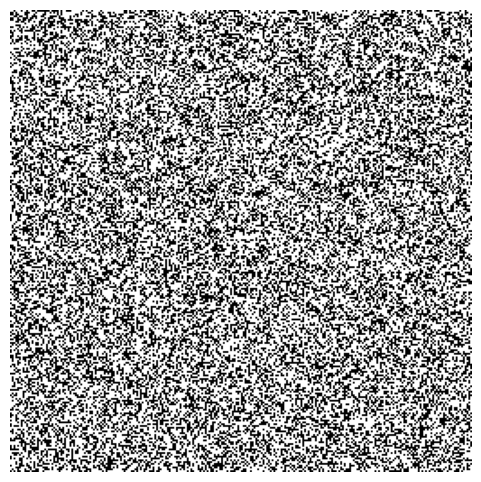

In [83]:
new_img, energy, energy_log, temp_log, history = simulated_annealing(img,NEIGHBOURHOODS['vertical_line'])
plot_binary_img(img)


### Po minimalizacji

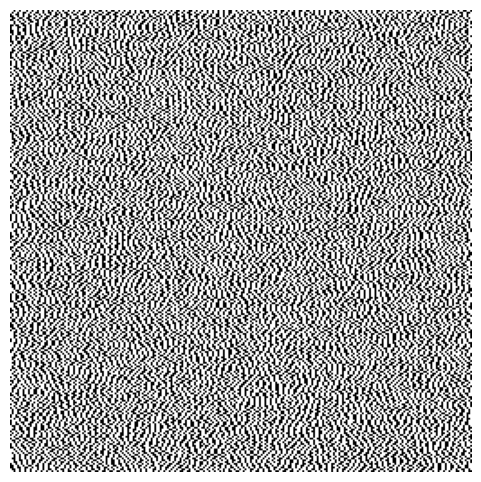

In [82]:
plot_binary_img(new_img)

### Funkcja do generowania gifów

In [ ]:
def simulated_annealing_gif(nb_key, local_energy_fn = repel_local_energy,  size=256, density=0.4):
    initial_img = generate_binary_image(size, density)
    _, _, energy_log, temp_log, history = simulated_annealing(
        initial_img, 
        nb = NEIGHBOURHOODS[nb_key], 
        local_energy_fn=local_energy_fn, 
        freezes=100
        )

    fig, (ax_plot, ax_img) = plt.subplots(1, 2, figsize=(12, 5))
    
    [line_en] = ax_plot.plot([], [], color='royalblue', label='Energy')
    ax_plot.set_xlim(0, len(energy_log))
    ax_plot.set_ylim(min(energy_log) - 5, max(energy_log) + 5)
    
    ax_temp = ax_plot.twinx()
    ax_temp.set_ylim(0, max(temp_log))
    [line_temp] = ax_temp.plot([], [], color='orange', label='Temp')

    img_disp = ax_img.imshow(history[0], cmap='binary')
    ax_img.axis('off')

    def animate(i):
        idx = i * (len(energy_log) // len(history))
        
        img_disp.set_data(history[i])
        
        line_en.set_data(np.arange(idx), energy_log[:idx])
        line_temp.set_data(np.arange(idx), temp_log[:idx])
        
        return img_disp, line_en, line_temp
    
    fn_name = local_energy_fn.__name__
    filename = f"./task_2_gifs/binary_image_annealing_{nb_key}_{fn_name.split('_')[0]}_d0{int(density*10)}_{size}.gif"
    ani = FuncAnimation(fig, animate, frames=len(history), interval=60, blit=True)
    ani.save(filename, writer='pillow')
    plt.close()
    
    return filename



### Przykładowy gif

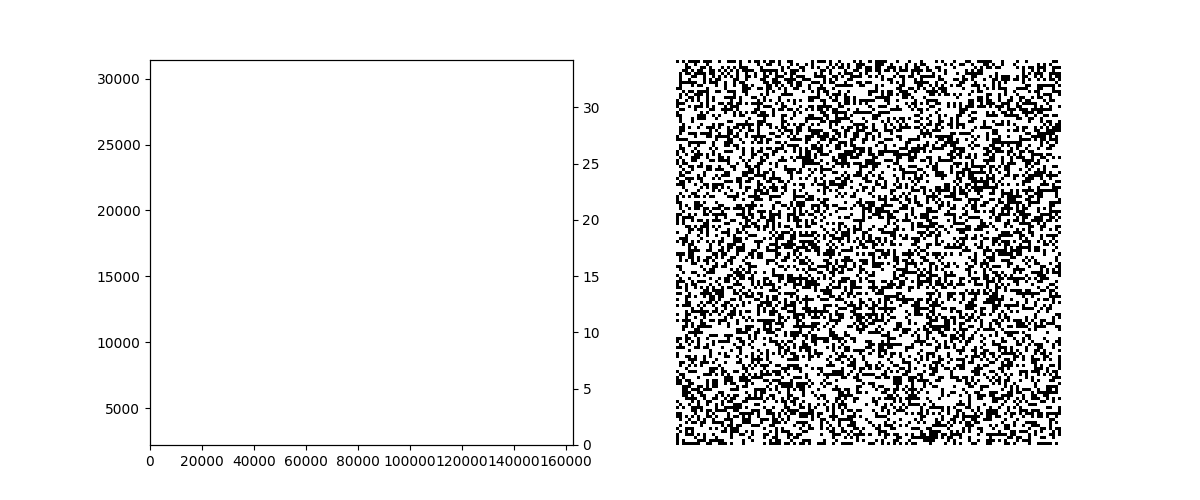

In [84]:
gif_path = simulated_annealing_gif(nb_key="vertical_line",local_energy_fn=pull_local_energy,size=128)
display(Image(filename=gif_path))

In [ ]:
results = Parallel(n_jobs=-1)(
    delayed(simulated_annealing_gif)(
        nb_key=nb_name, 
        local_energy_fn=fn, 
        size=size, 
        density=d,
    ) 
    for size in [128]
    for nb_name in NEIGHBOURHOODS.keys() 
    for fn in [repel_local_energy,pull_local_energy]
    for d in [0.4]
)

print(f"Generated: {results}")


KeyboardInterrupt: 

### W katalogu /task_2_gifs znajdują się wygenerowane gify dla kazdego sąsiedztwa, rozmiaru obrazka, rodzju funkcji energii i gęstości